In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
path = "../model/data/raw"
files = [
    "peakflow", "smartinhaler", "smartwatch1", "smartwatch2", "smartwatch3",
    "dailyquestionnaire", "weeklyquestionnaire", "endquestionnaire", "environment", "patient_info"
]

dfs = {f: pd.read_csv(f"{path}/anonym_aamos00_{f}.csv") for f in files}

# Feature Engineering

In [13]:
# Clean environment data
env_clean = dfs['environment'].drop_duplicates(subset=['user_key', 'date']).copy()
env_clean['grass_pollen'] = env_clean['grass_pollen'].astype('category')
env_clean['tree_pollen'] = env_clean['tree_pollen'].astype('category')
env_clean['weed_pollen'] = env_clean['weed_pollen'].astype('category')

# Clean peakflow data (average multiple intraday readings to get 1 row per day)
peakflow_clean = dfs['peakflow'].groupby(['user_key', 'date'])['pef_max'].mean().reset_index()

# Clean smartwatch data
dfs['smartwatch'] = pd.concat([dfs['smartwatch1'], dfs['smartwatch2'], dfs['smartwatch3']])
smartwatch = dfs['smartwatch'].copy()
smartwatch["is_running"] = smartwatch["activity_type"].isin([66, 98, 82])
smartwatch["is_sleep"] = smartwatch["activity_type"].isin([106, 112, 121, 122, 123])
smartwatch["is_sedentary"] = smartwatch["activity_type"].isin([80, 89, 90, 91, 92, 96])

activity_day_summary = smartwatch.groupby(["user_key", "date"]).agg(
    running_minutes=("is_running", "sum"),
    sleep_minutes=("is_sleep", "sum"),
    sedentary_minutes=("is_sedentary", "sum"),
    total_steps=("steps", "sum"),
    avg_hr=("hr", "mean")
).reset_index()


# 3. Initialize Base DataFrame (Daily Questionnaire)
daily = dfs['dailyquestionnaire'].drop_duplicates(subset=['user_key', 'date']).copy()

# Map inhaler mapping & define current day flare-up
inhaler_mapping = {0: 0, 1: 1.5, 3: 3.5, 5: 6.5, 9: 10.5, 12: 12}
daily['actual_puffs'] = daily['daily_relief_inhaler'].map(inhaler_mapping)
daily['is_flare_up'] = (
    (daily['actual_puffs'] >= 3) |
    (daily['daily_day_symp'] & daily['daily_limit_activity'] & daily['daily_night_symp'])
).astype(int)


# 4. Sequential Merges (Guaranteed to keep rows stable)
daily = pd.merge(daily, env_clean, on=['user_key', 'date'], how='inner')
daily = pd.merge(daily, peakflow_clean, on=['user_key', 'date'], how='left')
daily = pd.merge(daily, activity_day_summary, on=['user_key', 'date'], how='left')

# Ensure rows are perfectly sorted chronologically per user before shifting
daily = daily.sort_values(['user_key', 'date']).reset_index(drop=True)


# 5. Feature Engineering: Targets and Legitimate Lags
# Define target: Tomorrow's flare-up status
daily['tomorrow_flare_up'] = daily.groupby('user_key')['is_flare_up'].shift(-1)

# Calculate peakflow baselines and legitimate lags
def calculate_baseline(x):
    return x.nlargest(max(1, int(len(x) * 0.1))).mean()

baseline_values = daily.groupby("user_key")["pef_max"].apply(calculate_baseline).reset_index()
baseline_values.rename(columns={'pef_max': 'baseline_per_user'}, inplace=True)

daily = pd.merge(daily, baseline_values, on='user_key', how='left')
daily["pef_pct_best"] = daily["pef_max"] / daily['baseline_per_user']

# Chronological shifting on perfectly sequential, unique-date rows
daily["pef_pct_best_lag1"] = daily.groupby("user_key")['pef_pct_best'].shift(1)
daily["pef_change"] = daily["pef_pct_best"] - daily["pef_pct_best_lag1"]

# Lag smartwatch metrics to avoid current-day/intraday target pollution
daily['sedentary_minutes_lag'] = daily.groupby("user_key")['sedentary_minutes'].shift(1)
daily['running_minutes_lag'] = daily.groupby("user_key")['running_minutes'].shift(1)
daily['total_steps_lag'] = daily.groupby("user_key")['total_steps'].shift(1)
daily['avg_hr_lag'] = daily.groupby("user_key")['avg_hr'].shift(1)
daily['sleep_minutes_lag'] = daily.groupby("user_key")['sleep_minutes'].shift(1)
daily['temp_diff_tomorrow'] = daily.groupby('user_key')['temperature'].shift(-1) - daily['temperature']

# 6. Define Explicit Final Features (No current-day symptoms or target pollutants)
X_cols = [
    "temperature", "temperature_min", "temperature_max", "pressure", "humidity",
    "wind_speed", "wind_deg", "aqi", "co", "no", "no2", "o3", "so2", "pm2_5",
    "pm10", "nh3", "grass_pollen", "tree_pollen", "weed_pollen",
    "sleep_minutes_lag", "sedentary_minutes_lag", "running_minutes_lag",
    "total_steps_lag", "avg_hr_lag", "is_flare_up", "temp_diff_tomorrow" 
]
y_col = 'tomorrow_flare_up'

print(f"Final Dataframe Shape (Leak-Free): {daily.shape}")

Final Dataframe Shape (Leak-Free): (1500, 46)


In [14]:
display(daily.head())

,user_key,date,daily_night_symp,daily_day_symp,daily_limit_activity,daily_prev_inhaler,daily_relief_inhaler,daily_triggers,actual_puffs,is_flare_up,...,baseline_per_user,pef_pct_best,pef_pct_best_lag1,pef_change,sedentary_minutes_lag,running_minutes_lag,total_steps_lag,avg_hr_lag,sleep_minutes_lag,temp_diff_tomorrow
0,113,1,False,False,False,2,3,"5,9",3.5,1,...,412.166667,0.945006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.76
1,113,2,False,True,False,2,5,"5,9",6.5,1,...,412.166667,NaN,0.945006,NaN,509.0,0.0,19591.0,83.728114,582.0,0.40
2,113,3,False,False,False,2,1,"5,12",1.5,0,...,412.166667,0.703599,NaN,NaN,641.0,0.0,17615.0,85.743478,475.0,1.01
3,113,4,False,True,False,2,3,"5,9",3.5,1,...,412.166667,NaN,0.703599,NaN,577.0,0.0,20264.0,89.924469,507.0,2.74
4,113,5,False,True,False,2,3,"9,12",3.5,1,...,412.166667,NaN,NaN,NaN,603.0,0.0,9266.0,84.513693,535.0,-0.85


In [15]:
daily['is_flare_up'].value_counts(normalize=True)

is_flare_up
0    0.637333
1    0.362667
Name: proportion, dtype: float64

# Global Model Asthma Flare-up Prediction
In this section, we build a robust global model using chronological splits to prevent temporal leakage. We use environment, sensor data, and today's symptoms to predict tomorrow's flare-ups.

In [16]:
import os
import joblib
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score, accuracy_score, precision_score, classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

# Define categorical columns for encoding
categorical_cols = ['grass_pollen', 'tree_pollen', 'weed_pollen']

# 1. Clean and Prepare Global Data
daily_clean = daily.drop_duplicates(subset=['user_key', 'date']).copy()

# Features: Environment + Sensors + Today's Flare Status
# Target: Tomorrow's Flare Status
valid_features = [c for c in X_cols if c not in ['actual_puffs', 'daily_night_symp', 'daily_day_symp', 'daily_limit_activity', 'is_flare_up']] + ['is_flare_up']

temporal_df = daily_clean.dropna(subset=valid_features + [y_col]).sort_values(['user_key', 'date'])

# 2. Chronological Split (80% Train / 20% Test per user)
train_parts, test_parts = [], []
for _, user_df in temporal_df.groupby('user_key'):
    user_df = user_df.sort_values('date')
    split_idx = int(len(user_df) * 0.8)
    train_parts.append(user_df.iloc[:split_idx])
    test_parts.append(user_df.iloc[split_idx:])
train_data = pd.concat(train_parts, ignore_index=True)
test_data = pd.concat(test_parts, ignore_index=True)

X_train = pd.get_dummies(train_data[valid_features], columns=categorical_cols, drop_first=True)
y_train = train_data[y_col].astype(int)

X_test = pd.get_dummies(test_data[valid_features], columns=categorical_cols, drop_first=True)
y_test = test_data[y_col].astype(int)

# Align columns between train and test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 3. Model Training with Class Weighting
hw = (len(y_train) - y_train.sum()) / y_train.sum()
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, scale_pos_weight=hw, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# 4. Final Evaluation
probs = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
print(f"Final Chronological Test AUC: {roc_auc_score(y_test, probs):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# 5. Per-user metrics on each user's chronological hold-out
# Build from test_parts so user_key stays aligned even if test_data columns change
holdout_user_keys = []
for part in test_parts:
    holdout_user_keys.extend(part["user_key"].tolist())
eval_df = pd.DataFrame({
    "user_key": holdout_user_keys,
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred,
    "y_proba": probs,
})

per_user_results = []
for user, user_eval in eval_df.groupby("user_key"):
    y_true_u = user_eval["y_true"]
    y_pred_u = user_eval["y_pred"]
    row = {
        "user_key": user,
        "n_test_days": len(user_eval),
        "n_flares": int(y_true_u.sum()),
        "accuracy": accuracy_score(y_true_u, y_pred_u),
        "precision": precision_score(y_true_u, y_pred_u, zero_division=0),
        "recall": recall_score(y_true_u, y_pred_u, zero_division=0),
    }
    if y_true_u.nunique() > 1:
        row["auc"] = roc_auc_score(y_true_u, user_eval["y_proba"])
    else:
        row["auc"] = np.nan
    per_user_results.append(row)

per_user_df = pd.DataFrame(per_user_results).sort_values("user_key").reset_index(drop=True)
print("\nPer-user metrics (chronological hold-out):")
display(per_user_df)

# Summaries: macro (equal per user) vs weighted (equal per test day) vs flare-only users
weights = per_user_df["n_test_days"]
flare_users = per_user_df[per_user_df["n_flares"] > 0]

print("\n--- How to read these summaries ---")
print("Pooled metrics (classification report above) count every test day once.")
print("Macro mean counts every user once — small hold-outs and users with 0 flares")
print("  in test can make precision/recall look much worse than the pooled report.")

print("\nPooled (all hold-out days; matches classification report):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.3f}")

print("\nDay-weighted accuracy (matches pooled; each test day weighted equally):")
print(f"  Accuracy:  {np.average(per_user_df['accuracy'], weights=weights):.3f}")
print("  (Precision/recall are only meaningful when computed on pooled predictions above.)")

print(f"\nMacro mean across all {len(per_user_df)} users (each user weighted equally):")
print(f"  Accuracy:  {per_user_df['accuracy'].mean():.3f}")
print(f"  Precision: {per_user_df['precision'].mean():.3f}")
print(f"  Recall:    {per_user_df['recall'].mean():.3f}")

print(f"\nMacro mean — users with >=1 flare in hold-out only ({len(flare_users)} users):")
print(f"  Accuracy:  {flare_users['accuracy'].mean():.3f}")
print(f"  Precision: {flare_users['precision'].mean():.3f}")
print(f"  Recall:    {flare_users['recall'].mean():.3f}")


Final Chronological Test AUC: 0.889

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87       152
           1       0.74      0.82      0.78        78

    accuracy                           0.84       230
   macro avg       0.82      0.83      0.83       230
weighted avg       0.85      0.84      0.84       230


Per-user metrics (chronological hold-out):


,user_key,n_test_days,n_flares,accuracy,precision,recall,auc
0,113,30,5,0.700000,0.166667,0.200000,0.456000
1,190,27,0,1.000000,0.000000,0.000000,NaN
2,294,29,27,0.896552,0.928571,0.962963,0.314815
3,328,2,0,1.000000,0.000000,0.000000,NaN
4,343,24,1,0.875000,0.000000,0.000000,0.695652
5,398,5,0,0.600000,0.000000,0.000000,NaN
6,447,18,14,0.777778,0.812500,0.928571,0.625000
7,454,2,2,1.000000,1.000000,1.000000,NaN
8,473,8,5,0.375000,0.500000,0.600000,0.333333
9,514,7,1,0.714286,0.333333,1.000000,0.833333



--- How to read these summaries ---
Pooled metrics (classification report above) count every test day once.
Macro mean counts every user once — small hold-outs and users with 0 flares
  in test can make precision/recall look much worse than the pooled report.

Pooled (all hold-out days; matches classification report):
  Accuracy:  0.839
  Precision: 0.736
  Recall:    0.821

Day-weighted accuracy (matches pooled; each test day weighted equally):
  Accuracy:  0.839
  (Precision/recall are only meaningful when computed on pooled predictions above.)

Macro mean across all 18 users (each user weighted equally):
  Accuracy:  0.779
  Precision: 0.337
  Recall:    0.396

Macro mean — users with >=1 flare in hold-out only (12 users):
  Accuracy:  0.744
  Precision: 0.506
  Recall:    0.594


### Improving Data Retention with Iterative Imputation
To avoid losing patients due to occasional missing sensor or environmental data, we use `IterativeImputer`. This allows us to estimate missing values based on the distribution of other features.

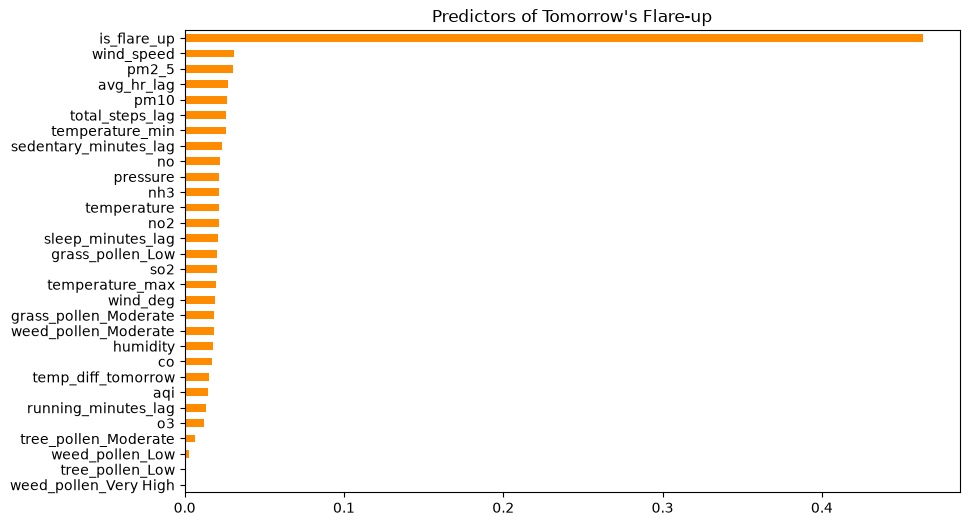

In [17]:
# Visualize Feature Importance
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='darkorange')
plt.title("Predictors of Tomorrow's Flare-up")
plt.show()

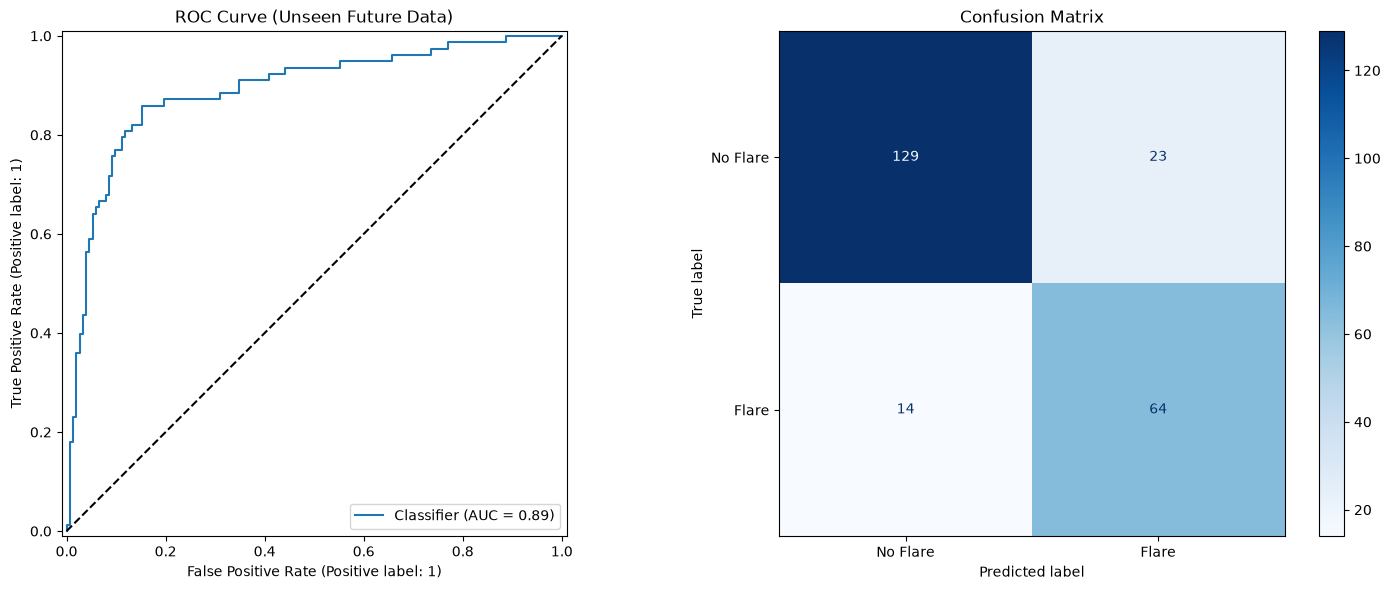

In [18]:
# Performance Visualization
from sklearn.metrics import RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve (from_predictions works across sklearn versions)
RocCurveDisplay.from_predictions(y_test, probs, ax=ax[0])
ax[0].plot([0, 1], [0, 1], "k--")
ax[0].set_title("ROC Curve (Unseen Future Data)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Flare", "Flare"]).plot(cmap="Blues", ax=ax[1])
ax[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

### Per-user metrics
Printed at the end of the **Global Model** training cell above.

If you still see a `KeyError` on `user_key` after restarting the kernel, VS Code may be running an old unsaved copy of this notebook. **Revert the file** (or close and reopen it), then **Run All** from the top.


# Personal Model Experiment

Skipping User 190: Insufficient data samples (134 total, 1.0 flares)
Skipping User 328: Insufficient data samples (7 total, 0.0 flares)
Skipping User 398: Insufficient data samples (23 total, 0.0 flares)
Skipping User 454: Insufficient data samples (7 total, 5.0 flares)
Skipping User 701: Insufficient data samples (85 total, 85.0 flares)
Skipping User 748: Insufficient data samples (1 total, 1.0 flares)
Skipping User 917: Insufficient data samples (6 total, 3.0 flares)

=== Personal Edge Model Evaluation Summary ===
Total individual models trained and saved: 11

Per-user metrics (chronological hold-out):


,user_key,total_samples,n_test_days,n_flares,test_auc,test_precision,test_recall,test_accuracy
0,113,146,30,5,0.472000,0.181818,0.400000,0.600000
1,294,144,29,27,0.148148,0.925926,0.925926,0.862069
2,343,120,24,1,0.913043,0.000000,0.000000,0.875000
3,447,90,18,14,0.660714,0.764706,0.928571,0.722222
4,473,37,8,5,0.400000,0.500000,0.600000,0.375000
5,514,31,7,1,0.333333,0.000000,0.000000,0.857143
6,625,29,6,2,0.750000,1.000000,0.500000,0.833333
7,702,107,22,0,NaN,0.000000,0.000000,0.954545
8,764,19,4,1,0.500000,0.000000,0.000000,0.750000
9,808,25,5,2,0.666667,0.500000,0.500000,0.600000



--- How to read these summaries ---
Pooled metrics count every edge hold-out day once across all personal models.
Macro mean counts every user once — tiny personal hold-outs (20% of one user)
  make per-user scores noisy; users with 0 test flares show precision/recall = 0.

Pooled (all edge hold-out days):
  AUC:       0.849
  Accuracy:  0.793
  Precision: 0.662
  Recall:    0.776

Day-weighted accuracy (matches pooled; each test day weighted equally):
  Accuracy:  0.793
  (Precision/recall are only meaningful when computed on pooled predictions above.)

Macro mean across all 11 users (each user weighted equally):
  AUC:       0.538
  Accuracy:  0.762
  Precision: 0.352
  Recall:    0.350

Macro mean — users with >=1 flare in hold-out only (9 users):
  AUC:       0.538
  Accuracy:  0.719
  Precision: 0.430
  Recall:    0.428


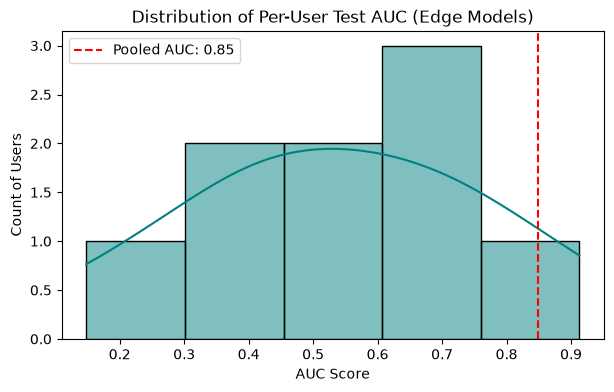

In [19]:
import os
import joblib
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    recall_score, accuracy_score, precision_score, classification_report,
    roc_auc_score, roc_curve, confusion_matrix
)

# Create a local directory to save the individualized models for Edge AI deployment
models_dir = "./edge_personal_models"
os.makedirs(models_dir, exist_ok=True)

# Define explicit features and categorical columns for consistent dummy encoding
categorical_cols = ['grass_pollen', 'tree_pollen', 'weed_pollen']
valid_features = [c for c in X_cols if c not in ['actual_puffs', 'daily_night_symp', 'daily_day_symp', 'daily_limit_activity', 'is_flare_up']] + ['is_flare_up']
y_col = 'tomorrow_flare_up'

# Drop missing target rows and sort strictly by timeline
temporal_df = daily.dropna(subset=valid_features + [y_col]).sort_values(['user_key', 'date']).copy()

# Pre-encode categorical features globally to ensure consistent column structure across all edge models
X_all_encoded = pd.get_dummies(temporal_df[valid_features], columns=categorical_cols, drop_first=True)
encoded_feature_names = X_all_encoded.columns.tolist()

# Reattach user information and targets
processed_df = pd.concat([temporal_df[['user_key', y_col]], X_all_encoded], axis=1)

individual_results = []
edge_eval_rows = []

# Loop through each individual user independently
for user, user_df in processed_df.groupby('user_key'):
    n_samples = len(user_df)
    n_positives = user_df[y_col].sum()

    # Check minimum operational data limits for training an isolated time-series edge model
    if n_samples < 15 or n_positives < 2 or (n_samples - n_positives) < 2:
        print(f"Skipping User {user}: Insufficient data samples ({n_samples} total, {n_positives} flares)")
        continue

    # 1. Isolated Chronological Split (Last 20% of personal history is completely unseen)
    split_idx = int(n_samples * 0.8)
    user_train = user_df.iloc[:split_idx]
    user_test = user_df.iloc[split_idx:]

    X_train_u = user_train[encoded_feature_names]
    y_train_u = user_train[y_col].astype(int)
    X_test_u = user_test[encoded_feature_names]
    y_test_u = user_test[y_col].astype(int)

    # 2. Dynamic Scale Position Weighting to counter individual flare-up imbalance
    pos_weight = (len(y_train_u) - y_train_u.sum()) / max(1, y_train_u.sum())

    # 3. Instantiate and train a shallow, high-efficiency edge model
    model_u = xgb.XGBClassifier(
        n_estimators=50,
        max_depth=3,
        scale_pos_weight=pos_weight,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss'
    )
    model_u.fit(X_train_u, y_train_u)

    # 4. Save individual weights for export to device
    model_filename = os.path.join(models_dir, f"model_{user}.joblib")
    joblib.dump(model_u, model_filename)

    # 5. Personal Evaluation on Unseen Future Timeline
    probs_u = model_u.predict_proba(X_test_u)[:, 1]
    preds_u = model_u.predict(X_test_u)

    edge_eval_rows.append(pd.DataFrame({
        "user_key": user,
        "y_true": y_test_u.to_numpy(),
        "y_pred": preds_u,
        "y_proba": probs_u,
    }))

    if len(np.unique(y_test_u)) > 1:
        auc_score = roc_auc_score(y_test_u, probs_u)
    else:
        auc_score = np.nan

    individual_results.append({
        "user_key": user,
        "total_samples": n_samples,
        "n_test_days": len(user_test),
        "n_flares": int(y_test_u.sum()),
        "test_auc": auc_score,
        "test_precision": precision_score(y_test_u, preds_u, zero_division=0),
        "test_recall": recall_score(y_test_u, preds_u, zero_division=0),
        "test_accuracy": accuracy_score(y_test_u, preds_u),
    })

results_df = pd.DataFrame(individual_results).sort_values("user_key").reset_index(drop=True)
edge_eval_df = pd.concat(edge_eval_rows, ignore_index=True)
y_edge = edge_eval_df["y_true"]
pred_edge = edge_eval_df["y_pred"]
probs_edge = edge_eval_df["y_proba"]

print("\n=== Personal Edge Model Evaluation Summary ===")
print(f"Total individual models trained and saved: {len(results_df)}")
print("\nPer-user metrics (chronological hold-out):")
display(results_df)

weights = results_df["n_test_days"]
flare_users = results_df[results_df["n_flares"] > 0]

print("\n--- How to read these summaries ---")
print("Pooled metrics count every edge hold-out day once across all personal models.")
print("Macro mean counts every user once — tiny personal hold-outs (20% of one user)")
print("  make per-user scores noisy; users with 0 test flares show precision/recall = 0.")

print("\nPooled (all edge hold-out days):")
print(f"  AUC:       {roc_auc_score(y_edge, probs_edge):.3f}")
print(f"  Accuracy:  {accuracy_score(y_edge, pred_edge):.3f}")
print(f"  Precision: {precision_score(y_edge, pred_edge, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_edge, pred_edge, zero_division=0):.3f}")

print("\nDay-weighted accuracy (matches pooled; each test day weighted equally):")
print(f"  Accuracy:  {np.average(results_df['test_accuracy'], weights=weights):.3f}")
print("  (Precision/recall are only meaningful when computed on pooled predictions above.)")

print(f"\nMacro mean across all {len(results_df)} users (each user weighted equally):")
print(f"  AUC:       {results_df['test_auc'].dropna().mean():.3f}")
print(f"  Accuracy:  {results_df['test_accuracy'].mean():.3f}")
print(f"  Precision: {results_df['test_precision'].mean():.3f}")
print(f"  Recall:    {results_df['test_recall'].mean():.3f}")

print(f"\nMacro mean — users with >=1 flare in hold-out only ({len(flare_users)} users):")
print(f"  AUC:       {flare_users['test_auc'].dropna().mean():.3f}")
print(f"  Accuracy:  {flare_users['test_accuracy'].mean():.3f}")
print(f"  Precision: {flare_users['test_precision'].mean():.3f}")
print(f"  Recall:    {flare_users['test_recall'].mean():.3f}")

if not results_df['test_auc'].dropna().empty:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=results_df, x='test_auc', kde=True, color='teal')
    pooled_auc = roc_auc_score(y_edge, probs_edge)
    plt.axvline(pooled_auc, color='red', linestyle='--', label=f"Pooled AUC: {pooled_auc:.2f}")
    plt.title("Distribution of Per-User Test AUC (Edge Models)")
    plt.xlabel("AUC Score")
    plt.ylabel("Count of Users")
    plt.legend()
    plt.show()


### Experiment: Global Model Pre-training + Individual Fine-tuning

This experiment tests the hypothesis that a global model, pre-trained on a larger population dataset, can provide a better starting point for individual personalization than training a model from scratch on limited individual data. We will iterate through each user:

1.  Train a global model *excluding* the current user.
2.  Fine-tune this global model using the current user's data.
3.  Evaluate the fine-tuned model's performance for that specific user.

Running Global + Personal Calibration Experiment

Users evaluated: 2

Per-user metrics:


,user_key,n_samples,n_test_days,n_test_flares,n_eval_days,n_eval_flares,auc_global,auc_calibrated,precision_global,precision_calibrated,recall_global,recall_calibrated,accuracy_global,accuracy_calibrated
0,113,146,30,5,15,4,0.464000,0.500000,0.20,0.250000,0.200000,0.250000,0.733333,0.600000
1,294,144,29,27,15,13,0.777778,0.730769,0.96,0.846154,0.888889,0.846154,0.862069,0.733333



--- How to read these summaries ---
Each user is evaluated on their chronological hold-out (last 20% of their timeline).
Calibration uses the first half of that hold-out to estimate bias, then evaluates on the second half.
Macro means count every user equally; pooled metrics count every test day equally.

GLOBAL MODEL (leave-one-user-out training)
Pooled (all hold-out days in this evaluation):
  AUC:       0.824
  Accuracy:  0.797
  Precision: 0.833
  Recall:    0.781

Day-weighted accuracy (matches pooled):
  Accuracy:  0.797

Macro mean across all 2 users:
  AUC:       0.621
  Accuracy:  0.798
  Precision: 0.580
  Recall:    0.544

Macro mean — users with >=1 flare in hold-out (2 users):
  AUC:       0.621
  Accuracy:  0.798
  Precision: 0.580
  Recall:    0.544

GLOBAL + PERSONAL CALIBRATION (second half of hold-out)
Pooled (all hold-out days in this evaluation):
  AUC:       0.792
  Accuracy:  0.667
  Precision: 0.706
  Recall:    0.706

Day-weighted accuracy (matches pooled):
  A

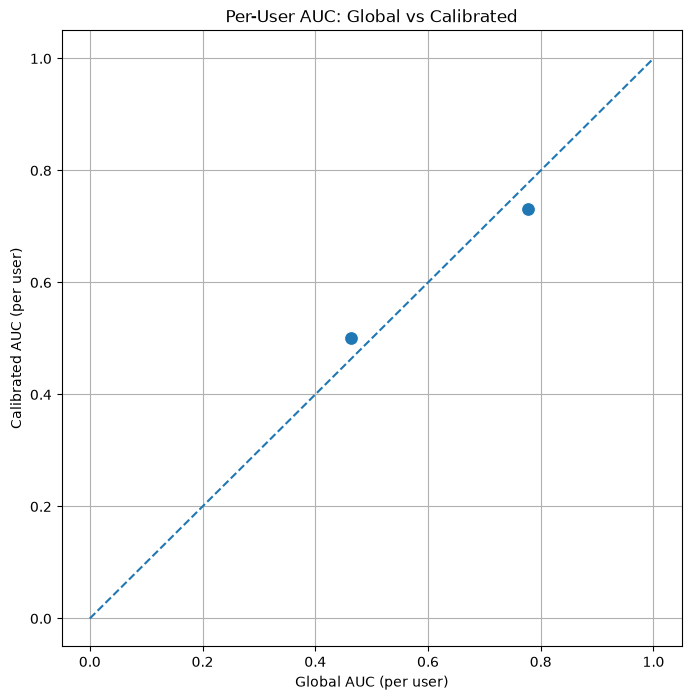

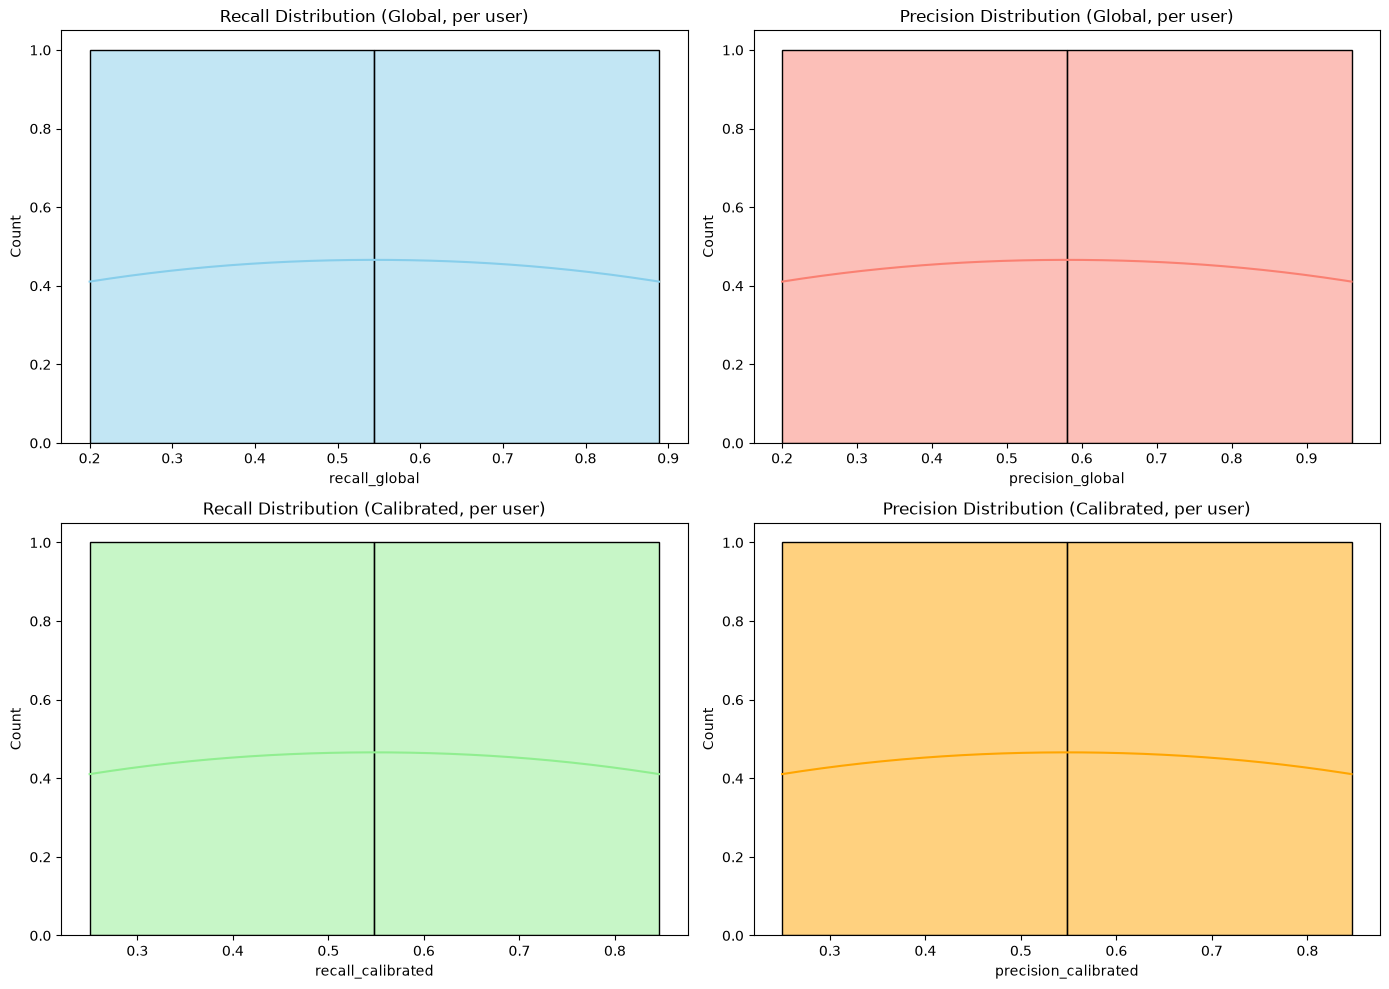


AUC improvement (per user)


,user_key,n_test_days,n_test_flares,auc_global,auc_calibrated,auc_gain
0,113,30,5,0.464000,0.500000,0.036000
1,294,29,27,0.777778,0.730769,-0.047009


In [20]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    accuracy_score
)

# =====================================================
# SETTINGS
# =====================================================

valid_features = [
    c for c in X_cols
    if c not in [
        "actual_puffs",
        "daily_night_symp",
        "daily_day_symp",
        "daily_limit_activity",
        "is_flare_up",
    ]
] + ["is_flare_up"]

MIN_USER_ROWS = 100

# =====================================================
# DATA
# =====================================================

df = (
    daily
    .dropna(subset=valid_features + [y_col])
    .sort_values(["user_key", "date"])
    .copy()
)

results = []
global_eval_rows = []
cal_eval_rows = []

print("Running Global + Personal Calibration Experiment")

# =====================================================
# LOOP OVER USERS
# =====================================================

for user in df["user_key"].unique():

    user_df = df[df["user_key"] == user].copy()

    if len(user_df) < MIN_USER_ROWS:
        continue

    global_train = df[df["user_key"] != user].copy()

    X_global = pd.get_dummies(
        global_train[valid_features],
        columns=categorical_cols,
        drop_first=True,
    )

    y_global = global_train[y_col].astype(int)

    split_idx = int(len(user_df) * 0.8)

    user_train = user_df.iloc[:split_idx]
    user_test = user_df.iloc[split_idx:]

    if len(user_test) < 20:
        continue

    X_test = pd.get_dummies(
        user_test[valid_features],
        columns=categorical_cols,
        drop_first=True,
    )

    X_test = X_test.reindex(
        columns=X_global.columns,
        fill_value=0,
    )

    y_test = user_test[y_col].astype(int)

    if y_test.nunique() < 2:
        continue

    pos_weight = (
        (len(y_global) - y_global.sum())
        / max(1, y_global.sum())
    )

    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=pos_weight,
        random_state=42,
    )

    model.fit(X_global, y_global)

    probs_global = model.predict_proba(X_test)[:, 1]
    preds_global = (probs_global >= 0.5).astype(int)

    auc_global = roc_auc_score(y_test, probs_global)
    precision_global = precision_score(y_test, preds_global, zero_division=0)
    recall_global = recall_score(y_test, preds_global, zero_division=0)
    acc_global = accuracy_score(y_test, preds_global)

    calibration_size = len(y_test) // 2
    y_cal = y_test.iloc[:calibration_size]
    p_cal = probs_global[:calibration_size]

    user_bias = y_cal.mean() - p_cal.mean()

    probs_calibrated = np.clip(
        probs_global[calibration_size:] + user_bias,
        0,
        1,
    )

    y_eval = y_test.iloc[calibration_size:]

    if len(np.unique(y_eval)) < 2:
        continue

    preds_calibrated = (probs_calibrated >= 0.5).astype(int)

    auc_cal = roc_auc_score(y_eval, probs_calibrated)
    precision_cal = precision_score(y_eval, preds_calibrated, zero_division=0)
    recall_cal = recall_score(y_eval, preds_calibrated, zero_division=0)
    acc_cal = accuracy_score(y_eval, preds_calibrated)

    cal_eval_rows.append(pd.DataFrame({
        "user_key": user,
        "y_true": y_eval.to_numpy(),
        "y_pred": preds_calibrated,
        "y_proba": probs_calibrated,
    }))

    global_eval_rows.append(pd.DataFrame({
        "user_key": user,
        "y_true": y_test.to_numpy(),
        "y_pred": preds_global,
        "y_proba": probs_global,
    }))

    results.append({
        "user_key": user,
        "n_samples": len(user_df),
        "n_test_days": len(user_test),
        "n_test_flares": int(y_test.sum()),
        "n_eval_days": len(y_eval),
        "n_eval_flares": int(y_eval.sum()),
        "auc_global": auc_global,
        "auc_calibrated": auc_cal,
        "precision_global": precision_global,
        "precision_calibrated": precision_cal,
        "recall_global": recall_global,
        "recall_calibrated": recall_cal,
        "accuracy_global": acc_global,
        "accuracy_calibrated": acc_cal,
    })

results_df = pd.DataFrame(results).sort_values("user_key").reset_index(drop=True)
global_eval_df = pd.concat(global_eval_rows, ignore_index=True)
cal_eval_df = pd.concat(cal_eval_rows, ignore_index=True)


def print_eval_summaries(per_user_df, eval_df, day_col, flare_col, label, metric_suffix):
    y_true = eval_df["y_true"]
    y_pred = eval_df["y_pred"]
    y_proba = eval_df["y_proba"]
    weights = per_user_df[day_col]
    flare_users = per_user_df[per_user_df[flare_col] > 0]
    acc_col = f"accuracy_{metric_suffix}"
    prec_col = f"precision_{metric_suffix}"
    rec_col = f"recall_{metric_suffix}"
    auc_col = f"auc_{metric_suffix}"

    print(f"\n{label}")
    print("Pooled (all hold-out days in this evaluation):")
    print(f"  AUC:       {roc_auc_score(y_true, y_proba):.3f}")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"  Recall:    {recall_score(y_true, y_pred, zero_division=0):.3f}")

    print("\nDay-weighted accuracy (matches pooled):")
    print(f"  Accuracy:  {np.average(per_user_df[acc_col], weights=weights):.3f}")

    print(f"\nMacro mean across all {len(per_user_df)} users:")
    print(f"  AUC:       {per_user_df[auc_col].dropna().mean():.3f}")
    print(f"  Accuracy:  {per_user_df[acc_col].mean():.3f}")
    print(f"  Precision: {per_user_df[prec_col].mean():.3f}")
    print(f"  Recall:    {per_user_df[rec_col].mean():.3f}")

    print(f"\nMacro mean — users with >=1 flare in hold-out ({len(flare_users)} users):")
    print(f"  AUC:       {flare_users[auc_col].dropna().mean():.3f}")
    print(f"  Accuracy:  {flare_users[acc_col].mean():.3f}")
    print(f"  Precision: {flare_users[prec_col].mean():.3f}")
    print(f"  Recall:    {flare_users[rec_col].mean():.3f}")


print("\nUsers evaluated:", len(results_df))
print("\nPer-user metrics:")
display(results_df)

print("\n--- How to read these summaries ---")
print("Each user is evaluated on their chronological hold-out (last 20% of their timeline).")
print("Calibration uses the first half of that hold-out to estimate bias, then evaluates on the second half.")
print("Macro means count every user equally; pooled metrics count every test day equally.")

print_eval_summaries(
    results_df, global_eval_df, "n_test_days", "n_test_flares", "GLOBAL MODEL (leave-one-user-out training)", "global"
)
print_eval_summaries(
    results_df, cal_eval_df, "n_eval_days", "n_eval_flares", "GLOBAL + PERSONAL CALIBRATION (second half of hold-out)", "calibrated"
)

# =====================================================
# SCATTER PLOT
# =====================================================

plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=results_df,
    x="auc_global",
    y="auc_calibrated",
    s=100,
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Global AUC (per user)")
plt.ylabel("Calibrated AUC (per user)")
plt.title("Per-User AUC: Global vs Calibrated")
plt.grid(True)
plt.show()

# =====================================================
# DISTRIBUTION PLOTS
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(results_df["recall_global"].dropna(), kde=True, color="skyblue", ax=axes[0, 0])
axes[0, 0].set_title("Recall Distribution (Global, per user)")
sns.histplot(results_df["precision_global"].dropna(), kde=True, color="salmon", ax=axes[0, 1])
axes[0, 1].set_title("Precision Distribution (Global, per user)")
sns.histplot(results_df["recall_calibrated"].dropna(), kde=True, color="lightgreen", ax=axes[1, 0])
axes[1, 0].set_title("Recall Distribution (Calibrated, per user)")
sns.histplot(results_df["precision_calibrated"].dropna(), kde=True, color="orange", ax=axes[1, 1])
axes[1, 1].set_title("Precision Distribution (Calibrated, per user)")
plt.tight_layout()
plt.show()

# =====================================================
# IMPROVEMENT TABLE
# =====================================================

results_df["auc_gain"] = results_df["auc_calibrated"] - results_df["auc_global"]

print("\nAUC improvement (per user)")

display(
    results_df[
        [
            "user_key",
            "n_test_days",
            "n_test_flares",
            "auc_global",
            "auc_calibrated",
            "auc_gain",
        ]
    ].sort_values("auc_gain", ascending=False)
)
